<a href="https://colab.research.google.com/github/yanin-dev/Repositorio-ModelizadoSistemas-/blob/main/Copia_de_Pracitica_Unidad_2_Algoritmos_Gen%C3%A9ticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problema:**
## **Optimización del Cronograma de una Vivienda**
### **Contexto:**

Una empresa constructora tiene que realizar 10 tareas críticas para entregar una casa (cimientos, muros, techos, instalaciones, etc.). Cada tarea tiene una duración estimada y requiere un número específico de operarios.


### **El Desafío:**

La empresa solo cuenta con una cuadrilla de 10 operarios en total. Si intentamos hacer muchas tareas en paralelo, superaremos ese límite. Si las hacemos todas en serie, la obra tardará meses.

### **Consigna:**

Desarrollar un modelo de Algoritmo Genético (usando PyGAD o DEAP) que encuentre el orden secuencial de inicio de tareas que minimice el tiempo total de la obra (Makespan) sin exceder nunca el límite de 10 operarios por día.

## Pasos para la Resolución (Hoja de Ruta)

**Modelado de Datos:** Crear una estructura (diccionario o lista) que contenga las 10 tareas, su duración en días y la cantidad de operarios necesarios para cada una.

**Definición del Cromosoma:** Determinar cómo representar la solución. Una forma sencilla es un vector de números reales o enteros que represente el "orden de prioridad" o el "día de inicio" de cada tarea.

**Diseño de la Función de Aptitud (Fitness):** La función debe recibir el orden de las tareas y calcular el día final de obra.

***Importante:*** Si en algún día la suma de operarios de las tareas activas supera los 10, la función debe aplicar una penalización drástica (bajar el fitness) para que esa solución sea descartada por el algoritmo.

Como queremos minimizar el tiempo, el fitness podría ser

$$Fitness = \frac{1}{DíasTotales}$$.

**Configuración del GA:** Definir el tamaño de la población (ej. 50 individuos). Elegir el método de selección (Torneo o Ruleta).Establecer una probabilidad de mutación para evitar que todos los cronogramas se vuelvan iguales rápido.

**Ejecución y Monitoreo:** Correr el proceso evolutivo y observar la curva de fitness para verificar que el tiempo total de la obra disminuya con las generaciones.

**Análisis de Resultados:** Mostrar cuál es el orden de tareas óptimo encontrado y confirmar que el uso de operarios sea legal (máximo 10).

**Razonamiento:**

*Piensen que el Algoritmo Genético aquí actúa como un Jefe de Obra virtual. Él va a probar miles de combinaciones de calendarios diferentes. Los que 'rompen' la regla de los operarios mueren rápido; los que logran terminar la casa un par de días antes, tienen hijos y pasan su estrategia a la siguiente generación.*

In [ ]:
# Instalación de las librerías necesarias
!pip install pygad deap matplotlib numpy

In [ ]:
# Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

## Si usan PyGAD:

In [ ]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

📌 Mejor orden de tareas:
[9 9 7 7 6 7 7 9 9 9]

📌 Fitness:
0.047619047619047616

📌 Duración total de la obra: 21 días


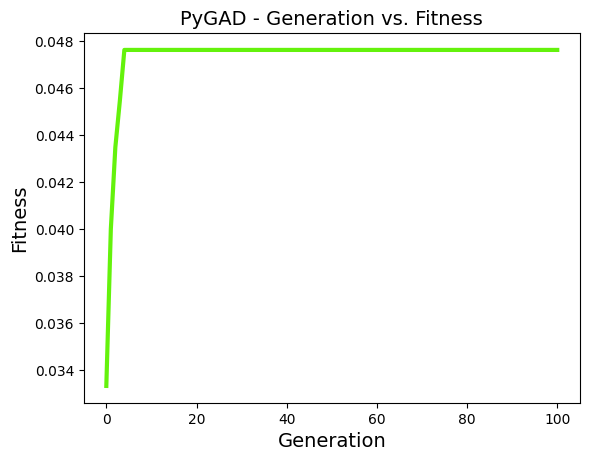

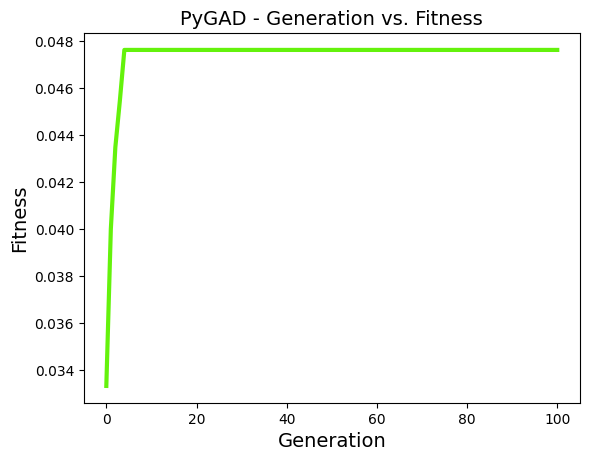

In [31]:
# ================================
# 1. INSTALAR LIBRERÍAS
# ================================

# Instalamos la librería pygad (solo la primera vez en Colab)
!pip install pygad


# ================================
# 2. IMPORTAR LIBRERÍAS
# ================================

import pygad  # Librería que implementa el algoritmo genético
import numpy as np  # Para trabajar con números (aunque acá casi no se usa)
import matplotlib.pyplot as plt  # Para graficar resultados


# ================================
# 3. DATOS DEL PROBLEMA
# ================================

# Diccionario de tareas:
# clave = número de tarea
# valor = (duración en días, cantidad de operarios)
TAREAS_OBRA = {
    0: (5, 4),  # Cimientos → 5 días, 4 operarios
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

# Máximo de operarios permitidos por día
MAX_OPERARIOS = 10

# Cantidad total de tareas (en este caso 10)
NUM_TAREAS = len(TAREAS_OBRA)


# ================================
# 4. FUNCIÓN FITNESS (LA MÁS IMPORTANTE)
# ================================

# Esta función evalúa qué tan buena es una solución (orden de tareas)
def fitness_func(ga_instance, solution, solution_idx):

    # Variable que guarda el tiempo total de la obra
    tiempo_total = 0

    # Lista donde guardamos cuántos operarios se usan cada día
    operarios_por_dia = []

    # Recorremos cada tarea según el orden propuesto por el algoritmo
    for tarea in solution:

        # Convertimos a entero (por seguridad)
        tarea = int(tarea)

        # Obtenemos duración y operarios de esa tarea
        duracion, operarios = TAREAS_OBRA[tarea]

        # Recorremos cada día que dura la tarea
        for dia in range(duracion):

            # Si ese día todavía no existe en la lista, lo agregamos
            if len(operarios_por_dia) <= tiempo_total + dia:
                operarios_por_dia.append(0)

            # Sumamos los operarios de la tarea en ese día
            operarios_por_dia[tiempo_total + dia] += operarios

        # Sumamos la duración de la tarea al tiempo total
        tiempo_total += duracion

    # ================================
    # VALIDACIÓN (RESTRICCIÓN IMPORTANTE)
    # ================================

    # Verificamos que ningún día supere el máximo de operarios
    for op in operarios_por_dia:
        if op > MAX_OPERARIOS:
            return 0.0001  # Penalización fuerte (solución mala)

    # ================================
    # RESULTADO FINAL (FITNESS)
    # ================================

    # Queremos minimizar el tiempo → usamos 1/tiempo
    return 1 / tiempo_total


# ================================
# 5. CONFIGURAR ALGORITMO GENÉTICO
# ================================

# Creamos el algoritmo genético con sus parámetros
ga_instance = pygad.GA(

    num_generations=100,  # Cantidad de iteraciones (más = mejor resultado)

    num_parents_mating=10,  # Cuántas soluciones se cruzan

    fitness_func=fitness_func,  # Función que evalúa las soluciones

    sol_per_pop=50,  # Cantidad de soluciones por generación

    num_genes=NUM_TAREAS,  # Cantidad de genes (una por tarea)

    gene_type=int,  # Los valores son enteros

    init_range_low=0,  # Valores mínimos posibles
    init_range_high=NUM_TAREAS,  # Valores máximos posibles

    mutation_percent_genes=10  # Porcentaje de mutación
)


# ================================
# 6. EJECUTAR EL ALGORITMO
# ================================

# Acá empieza a trabajar el algoritmo genético
ga_instance.run()


# ================================
# 7. OBTENER RESULTADOS
# ================================

# Obtenemos la mejor solución encontrada
solution, solution_fitness, _ = ga_instance.best_solution()

print("📌 Mejor orden de tareas:")
print(solution)  # Ejemplo: [2 0 1 3 ...]

print("\n📌 Fitness:")
print(solution_fitness)


# ================================
# 8. CALCULAR DÍAS TOTALES
# ================================

# Convertimos el fitness nuevamente a días
dias_totales = int(1 / solution_fitness)

print("\n📌 Duración total de la obra:", dias_totales, "días")


# ================================
# 9. GRÁFICO DE EVOLUCIÓN
# ================================

# Muestra cómo fue mejorando el algoritmo
ga_instance.plot_fitness()

## Si usan DEAP:

In [ ]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt